# Least Squares Approximation – Assignment 2

This notebook applies the Least Squares (LS) method to approximate a noisy signal using a polynomial model.

## Problem Description

We approximate a noisy signal:

x(n) = 2 sin(0.05πn) + noise

using a polynomial model:

x̂(n) = c1 + c2·n + c3·n²

The goal is to find coefficients (c1, c2, c3) that minimize the squared error.

## 1. Least Squares Method

The coefficients are found by minimizing the cost function:

J = Σ (x(n) - x̂(n))²

This leads to a linear system:

c = (AᵀA)⁻¹ Aᵀ x

## 2. Signal and Model

The noisy signal is generated and the design matrix A is constructed:

A = [1, n, n²]

In [8]:
import numpy as np, matplotlib.pyplot as plt

rng = np.random.default_rng()

def generate_data():
    n = np.arange(1, 21, dtype=float)
    s = 2*np.sin(0.05*np.pi*n)
    noise = rng.normal(0, 0.5, size=n.size)
    z = s + noise
    Phi = np.column_stack([np.ones_like(n), n, n**2])
    return n, s, z, Phi

n, s, z, Phi = generate_data()
print("ok", n.size)

ok 20


## 3. Least Squares Solution

The coefficients are computed using the least squares method.

c [-0.3091  0.4681 -0.0233]
J 4.0803


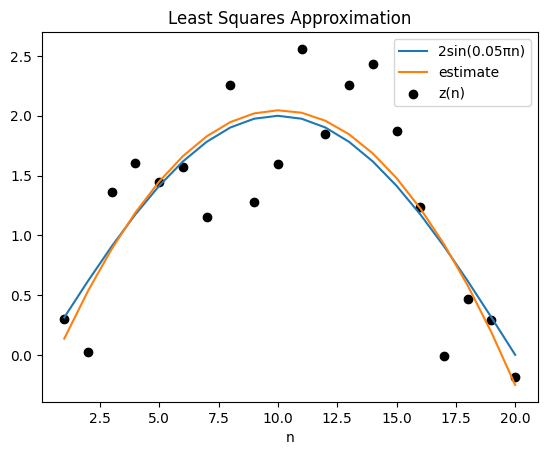

In [12]:
c, *_ = np.linalg.lstsq(Phi, z, rcond=None)
yhat = Phi @ c
J = np.sum((z - yhat)**2)

print("c", np.round(c,4))
print("J", round(J,4))

plt.figure()
plt.title("Least Squares Approximation")

plt.plot(n, s, label="2sin(0.05πn)")
plt.plot(n, yhat, label="estimate")
plt.scatter(n, z, label="z(n)", color="k")

plt.xlabel("n")
plt.legend()
plt.show()

In [3]:
R = 20
C = []
JJ = []

for _ in range(R):
    n_i, s_i, z_i, Phi_i = generate_data()
    c_i, *_ = np.linalg.lstsq(Phi_i, z_i, rcond=None)
    y_i = Phi_i @ c_i
    J_i = np.sum((z_i - y_i)**2)
    C.append(c_i)
    JJ.append(J_i)

C = np.array(C)
JJ = np.array(JJ)

def stats(v):
    return [v.min(), v.max(), v.mean(), v.std()]

print("c1", np.round(stats(C[:,0]),4))
print("c2", np.round(stats(C[:,1]),4))
print("c3", np.round(stats(C[:,2]),4))
print("J",  np.round(stats(JJ),4))

c1 [1.0125 2.4331 1.8188 0.3274]
c2 [-0.4868 -0.2522 -0.3702  0.0668]
c3 [0.0115 0.023  0.0166 0.0034]
J [26.0888 43.9688 36.4839  5.0678]


## 4. Results

The estimated signal is compared with the noisy and clean signals.

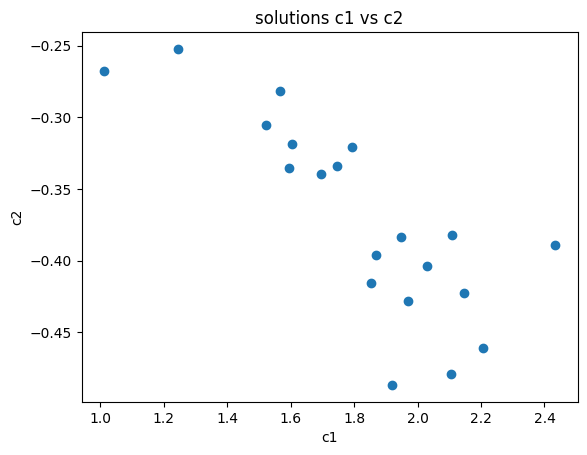

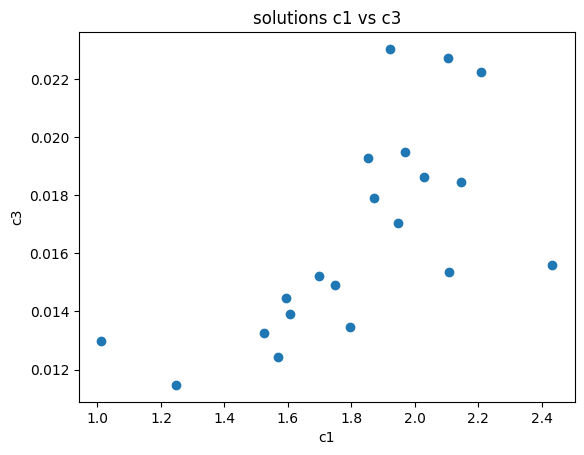

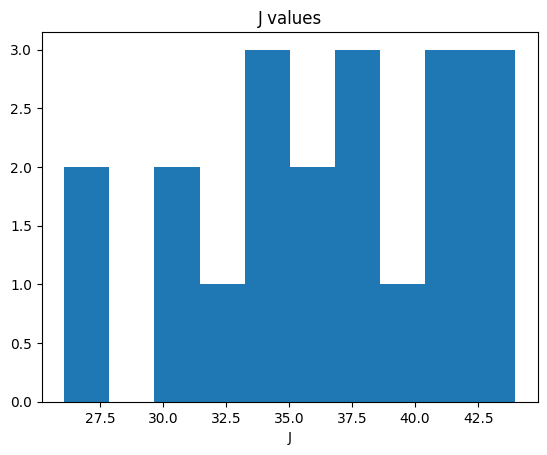

In [4]:
plt.figure()
plt.scatter(C[:,0], C[:,1])
plt.xlabel("c1")
plt.ylabel("c2")
plt.title("solutions c1 vs c2")
plt.show()

plt.figure()
plt.scatter(C[:,0], C[:,2])
plt.xlabel("c1")
plt.ylabel("c3")
plt.title("solutions c1 vs c3")
plt.show()

plt.figure()
plt.hist(JJ, bins=10)
plt.xlabel("J")
plt.title("J values")
plt.show()

**Observation:**

The LS estimate follows the general shape of the original signal while reducing the effect of noise.  
The polynomial captures the trend but cannot perfectly model the sinusoidal shape.

## Parameter Interpretation

- c1 → constant offset  
- c2 → linear trend  
- c3 → curvature  
- J → total squared error (fit quality)

## 5. Bonus

To better understand the behavior of the Least Squares method, we test how the estimated coefficients change when the noise is different.

In [6]:
# BONUS: Testing higher-order polynomials

def run_ls(k):
    n = np.arange(1, 21, dtype=float)
    s = 2*np.sin(0.5*n)
    noise = rng.normal(0, 0.5, size=n.size)
    z = s + noise
    Phi = np.column_stack([n**i for i in range(k)])
    c, *_ = np.linalg.lstsq(Phi, z, rcond=None)
    yhat = Phi @ c
    J = np.sum((z - yhat)**2)
    return J

orders = [3, 4, 5, 8]
J_values = {}

for k in orders:
    J_values[k] = run_ls(k)

print("J values for different polynomial orders:")
for k in orders:
    print(f"Order {k}: J = {J_values[k]:.4f}")


J values for different polynomial orders:
Order 3: J = 31.5542
Order 4: J = 18.1154
Order 5: J = 5.5961
Order 8: J = 4.0659


**Observation:**

The coefficients change due to different noise realizations, but the overall trend of the signal remains similar.

## 6. Conclusion

- Least Squares successfully approximates the noisy signal  
- The polynomial captures the overall trend  
- The method minimizes the squared error J  
- Noise affects the estimated coefficients